# Практическая работа 3: "Предобработка изображений с использованием библиотеки OpenCV"

**Задание 1**. Подключение библиотеки OpenCV

Если есть в этом необходимость, то установите библиотеку `!pip install opencv-python`.  

In [ ]:
import cv2
print(cv2.__version__)

**Задание 2**. Начало работы с OpenCV

2.1.   Перед началом работы нужно загрузить на Google Диск все необходимые для работы изображения.

2.2.   Затем подключить Google Диск к данному Notebook  либо через меню «Файлы» (значок папки) -> «Подключить диск», либо прописав приведенный код самостоятельно:
```
from google.colab import drive
drive.mount('/content/drive')
```
Это позволяет читать и сохранять данные напрямую, используя путь к файлам, который будет начинаться с `/content/drive/MyDrive/`

In [ ]:
#ВАШ КОД

2.3.   Далее выберите любое понравившееся Вам изображение и загрузите его для работы.

In [ ]:
import numpy as np
from pathlib import Path

path = Path(r"PATH") #вставьте путь к файлу

img = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR) #в случае наличия в пути кириллицы

print(img.shape)

2.4. Выведем изображение на экран, используя библиотеку Matplotlib.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')

**Задание 3**. Поработаем с цветом

3.1. Представьте изображение в исходной цветовой палитре.

3.2. Представьте изображение в градации серого.

3.3. Представьте изображение в черно-белом формате.

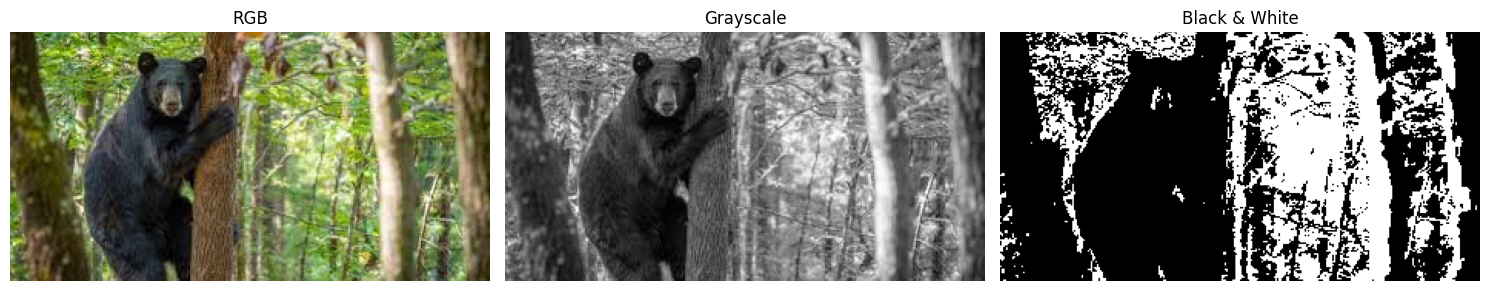

In [ ]:
#ВАШ КОД, пример вывода смотри ниже

Ответьте на следующие вопросы:

1.   Какой формат цвета использует OpenCV? Какие особенности работы в этим форматом нужно учитывать?
2.   Для чего может понадобиться преобразование цвета?

Ответы на вопросы:

1.

2.

**Задание 4**. Операции с изображением

4.1. Необходимо уменьшить изображение в три раза, используя, например команду `resize()`.

4.2. Необходимо уменьшить изображение, задав итоговый размер.

4.3. Обрежьте изображение так, чтобы остался только ваш объект.

4.4. Поверните изображение от 30 до 180 градусов с шагом 30 градусов.

4.5. Используйте размытие изображения для удаления шумов.

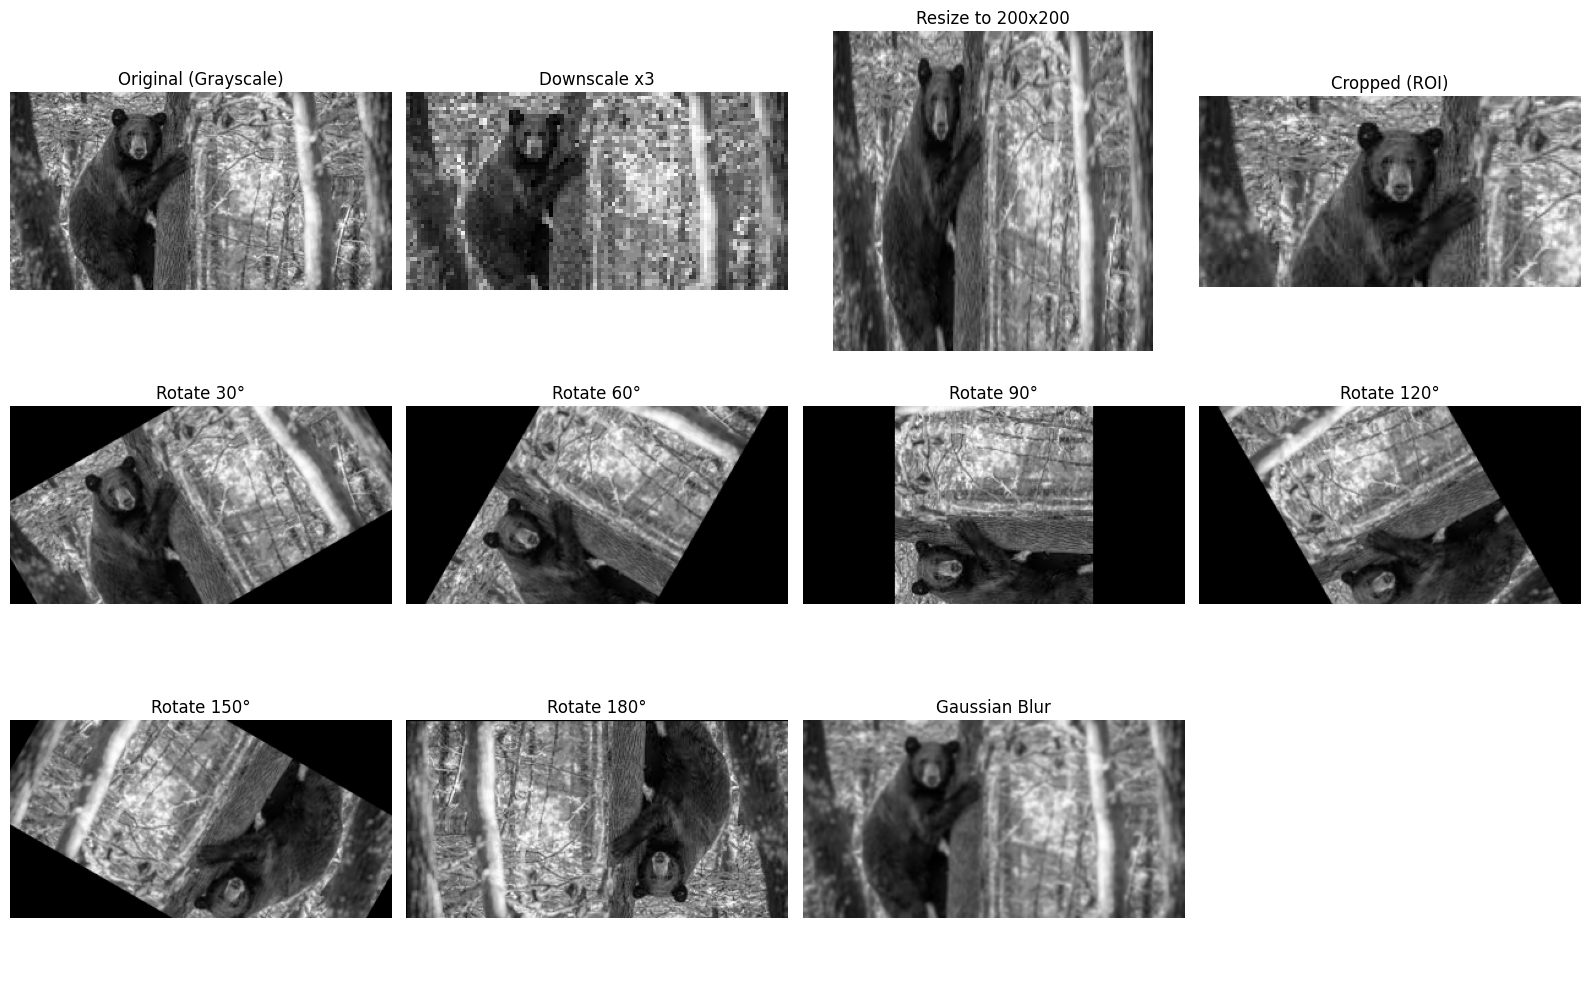

In [ ]:
#ВАШ КОД, пример вывода смотри ниже

**Задание 5**. Детекция объектов

**Детекция объектов** (*Object Detection*) — это задача компьютерного зрения, объединяющая классификацию (что изображено) и локализацию (где находится) объектов на изображении или видео. Она находит объекты, рисуя вокруг них ограничивающие рамки (bounding boxes) с метками классов и оценкой достоверности.

Выделить контуры вашего объекта, используйте ***drawContours()***.

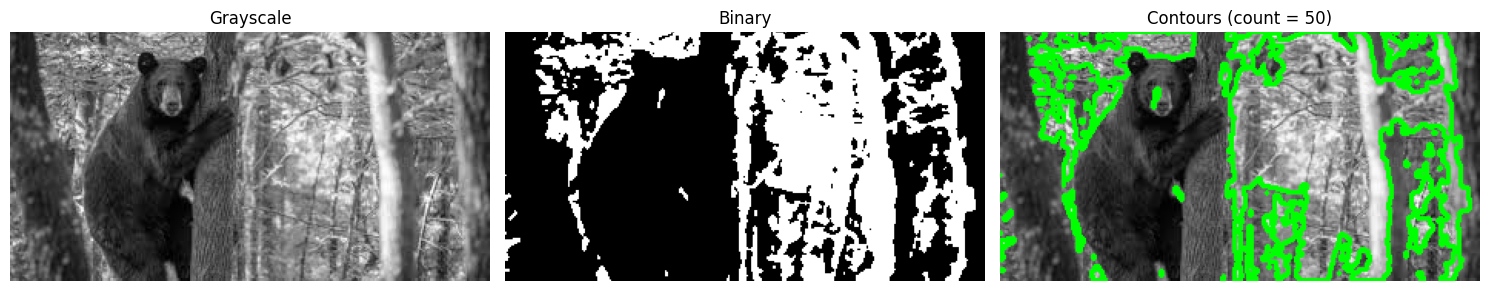

In [ ]:
#ВАШ КОД, пример вывода смотри ниже

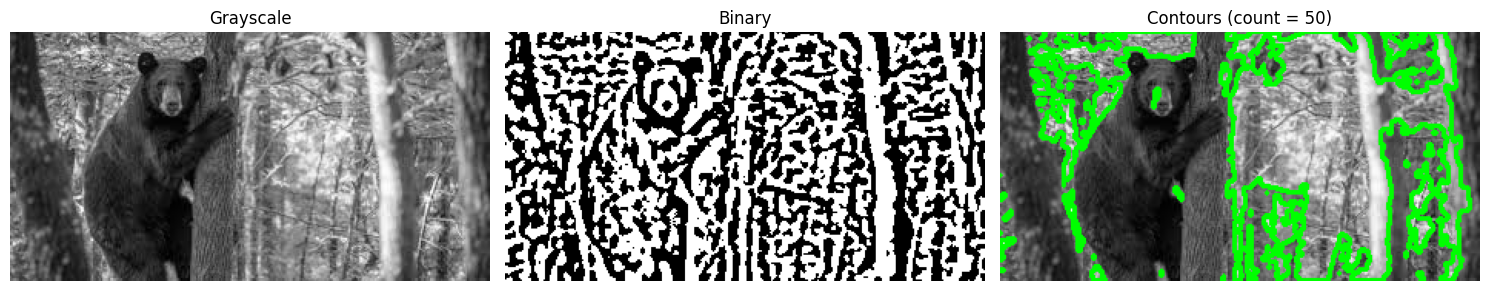

In [ ]:
#Для сложного фона
#ВАШ КОД, пример вывода смотри ниже

**Задание 6**. Применение набора данных для решение задачи классификации

Попробуем выполнить классификацию изображений по 5 классам медведей. И проверим качество работы модели на конкретном примере `eхample.jpg`.

In [ ]:
import os

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
DATASET_PATH = "PATH"       #вставьте путь к файлу
CLASSES = ["black", "grizzly", "panda", "polar", "teddy"]

images = []
labels = []

for label, cls in enumerate(CLASSES):
    class_path = os.path.join(DATASET_PATH, cls)

    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img_gray = cv2.resize(img_gray, (128, 128))

        images.append(img_gray)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

print(X.shape, y.shape)

In [ ]:
from skimage.feature import hog

In [ ]:
def extract_hog_features(images):
    features = []

    for img in images:
        hog_feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        features.append(hog_feat)

    return np.array(features)

In [ ]:
X_features = extract_hog_features(X)

print(X_features.shape)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
model = SVC(kernel='linear', probability=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=CLASSES))

In [ ]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.resize(img_gray, (128, 128))

    feat = extract_hog_features([img_gray])
    pred = model.predict(feat)[0]

    return CLASSES[pred]

print(predict_image("PATH"))         #вставьте путь к файлу

img = cv2.imread("PATH")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Predicted: {predict_image('PATH')}")
plt.axis('off')
plt.show()

Вопрос:

1.   Почему получен такой результат?
2.   Как можно повысить качество модели?


Ваши ответы:

1.   ...
2.   ...






**Задание 7**. **NoCode** платформы для работы с данными.


 7.1. Перейти по ссылке https://app.roboflow.com/login.

 7.2. Пройдите процедуру регистрации.

 7.3. Создайте свой собственный проект.

 7.4. Выберите загрузку собственных данных.

 7.5. Заполните название проекта, выберите тип лицензии, тип вашего проекта и кратко укажите что будет вашей целью.

 7.6. Загрузите ваши изображения (не менее 30) в проект.

 7.7. Выполните ручную разметку данных.

 7.8. После того как все изображения размечены, добавьте эту разметку к вашему набору данных.

7.9. Разделите данные на обучающую, тестовую и валидационную выборки.

7.10. После этого можно сгенерировать новую версию датасета, уже готового к обучению.

7.11. Внимательно изучаем доступные параметры и выбираем то, что позволит сделать ваш набор данных лучше для обучения. Например, выбираем параметры предобработки и аументации.

7.12. В качестве ***ответа на задание*** необходимо вставить ***скриншот проекта*** из браузера с разметкой.